# **Rush 3: Customer Satisfaction — Airline Company**
**Exploratory analysis, explanatory factors & satisfaction prediction (Machine Learning, binary classification)**

### ***Author:***
**Cedric Enzo KOUOKAM KAMHOUA**



**Context:** Data/BI consultant for an airline company.

**Mission:** identify the key explanatory factors behind customer satisfaction and develop a classification algorithm capable of predicting passenger satisfaction levels.

**Source:** `train.csv` (103,904 rows) / `test.csv` (25,976 rows), provided by the airline. The dataset is already split into train / external test.

**Target variable analyzed:** `satisfaction` → binary, `satisfied` / `neutral or dissatisfied`.

#### Table of Contents

1. Setup & Imports
2. Loading & Overview
3. Data Cleaning
4. Target variable: `satisfaction` & business objective

***EDA:***

5. Exploratory analysis
   - 5.1 Traveler profile: travel type, class, loyalty
   - 5.2 Perceived service quality vs punctuality
   - 5.3 Age effect
   - 5.4 Correlations, multicollinearity & statistical tests
   - 5.5 EDA summary

***Modeling:***

6. Feature engineering
7. Machine Learning
   - 7.1 Train / validation / external test split
   - 7.2 Preprocessing (encoding, imputation, scaling)
   - 7.3 Class imbalance strategy
   - 7.4 Logistic Regression (baseline → tuning → final)
   - 7.5 KNN (baseline → tuning → final)
8. Model evaluation & comparison
9. Model interpretation
10. Limitations & biases
11. Methodological choices
12. Conclusion

## **1. Setup & Imports**

In [1]:
# uncomment if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)

## **2. Loading & Overview**

In [3]:
DATA_DIR = "."
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"train : {train.shape}")
print(f"test  : {test.shape}")

print(f'\nColumn types:')
print(train.dtypes.value_counts())
train.head(10)

train : (103904, 25)
test  : (25976, 25)

Column types:
int64      19
object      5
float64     1
Name: count, dtype: int64


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2,1,1,2,1,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2,3,2,2,2,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4,4,5,5,5,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2,2,4,3,3,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3,4,2,3,3,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [5]:
# Summary statistics for numeric columns
print('DESCRIPTIVE STATISTICS: NUMERIC COLUMNS')

train.describe().T


DESCRIPTIVE STATISTICS: NUMERIC COLUMNS


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


In [6]:
print('DESCRIPTIVE STATISTICS: CATEGORICAL COLUMNS')
display(train.describe(include=['object']).T)

DESCRIPTIVE STATISTICS: CATEGORICAL COLUMNS


,count,unique,top,freq
Gender,103904,2,Female,52727
Customer Type,103904,2,Loyal Customer,84923
Type of Travel,103904,2,Business travel,71655
Class,103904,3,Business,49665
satisfaction,103904,2,neutral or dissatisfied,58879


**Observations on the descriptive statistics:**
- `Age`: from 7 to 85 years old, mean 39.4; minors are present in the dataset (respondents traveling with a companion, potentially less reliable on some service ratings).
- The 14 service rating variables (`Inflight wifi service`, `Seat comfort`, ...) are all on a **0 to 5** scale, where 0 likely means "not applicable / not rated" rather than a genuinely negative score.
- `Flight Distance`: from 31 to 4983, very spread out (short-haul and long-haul flights mixed together).
- `Departure Delay in Minutes` and `Arrival Delay in Minutes` are **highly skewed** (median at 0, max > 1580 minutes, i.e. more than 26h): most flights have no delay at all, a minority of extreme cases pull the mean upward.
- `Unnamed: 0` is a simple row index (0..N-1), likely to be dropped.
- `Business travel` and `Loyal Customer` are dominant

In [7]:
# Missing values
missing = train.isna().sum()
missing = missing[missing > 0]
print("Missing values (train data):")
print(missing, f"\n-> {(missing/len(train)*100).round(3).values[0]}% of rows")

miss_test = test.isna().sum()
miss_test = miss_test[miss_test > 0]
print("\nMissing values (test data):")
print(miss_test)

Missing values (train data):
Arrival Delay in Minutes    310
dtype: int64 
-> 0.298% of rows

Missing values (test data):
Arrival Delay in Minutes    83
dtype: int64


Only `Arrival Delay in Minutes` has missing values: 310 rows (0.30%) in train, 83 (0.32%) in test. This is marginal and concentrated in a single column, so a simple treatment will be sufficient.

In [8]:
# Frequency of rating = 0 across the 14 service rating columns

service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
       'Ease of Online booking', 'Gate location', 'Food and drink',
       'Online boarding', 'Seat comfort', 'Inflight entertainment',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Inflight service', 'Cleanliness']

zero_rate = (train[service_cols] == 0).mean().sort_values(ascending=False) * 100
zero_rate.round(2)

Departure/Arrival time convenient    5.10
Ease of Online booking               4.32
Inflight wifi service                2.99
Online boarding                      2.34
Leg room service                     0.45
Food and drink                       0.10
Inflight entertainment               0.01
Cleanliness                          0.01
On-board service                     0.00
Inflight service                     0.00
Gate location                        0.00
Seat comfort                         0.00
Checkin service                      0.00
Baggage handling                     0.00
dtype: float64

A rating of 0 on the 14 service variables remains rare: at most 5.1% of rows for `Departure/Arrival time convenient`, and nearly zero (< 2.99%) for almost all the others (`Baggage handling`, `Seat comfort`, `Gate location`... have almost none). So this isn't a massive problem that would distort the analysis.

But the question of how to handle these 0s still needs to be addressed — it's settled in section 3 (cleaning).

In [9]:
# Duplicate detection

print("Duplicated IDs:", train['id'].duplicated().sum())
print("Fully duplicated rows:", train.duplicated().sum())


Duplicated IDs: 0
Fully duplicated rows: 0


In [10]:
# Satisfaction distribution across train & test
print("Consistent satisfaction distribution Train / Test:")
print(pd.concat([
    train['satisfaction'].value_counts(normalize=True).rename('Train'),
    test['satisfaction'].value_counts(normalize=True).rename('Test')
], axis=1).round(4) * 100)

Consistent satisfaction distribution Train / Test:
                         Train  Test
satisfaction                        
neutral or dissatisfied  56.67  56.1
satisfied                43.33  43.9


No duplicates, no duplicated IDs: the dataset is structurally clean. The target distribution is nearly identical between `train` (56.7% / 43.3%) and `test` (56.1% / 43.9%); the split provided by the airline is representative, which makes the final evaluation on `test.csv` fairly reliable.

## **3. Data Cleaning**

In [11]:
for df in (train, test):
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"train : {train.shape}, test : {test.shape}")

train : (103904, 24), test : (25976, 24)


`Unnamed: 0` is an export artifact (a duplicated row index) with no predictive value. `id` is kept aside (passenger identifier) but will be excluded from the features at modeling time.

In [12]:
# Analyzing the informativeness of the missing values

# correlation between the two delays
print("Departure / arrival delay correlation:",
      train[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].corr().iloc[0, 1].round(3))


print("\nProfile of rows with missing Arrival Delay:")
print(train.loc[train['Arrival Delay in Minutes'].isna(), 'Departure Delay in Minutes'].describe())

Departure / arrival delay correlation: 0.965

Profile of rows with missing Arrival Delay:
count    310.000000
mean      37.432258
std       62.239283
min        0.000000
25%        0.000000
50%        8.000000
75%       47.500000
max      455.000000
Name: Departure Delay in Minutes, dtype: float64


- The missing column `Arrival Delay in Minutes` is very strongly correlated with the `departure delay` ( > 0.96): a missing arrival delay is therefore not a special case, it follows the same logic as a typical delay — if a flight departs late, it almost always arrives with a very similar delay.
- The 310 rows concerned have entirely plausible departure delays (from 0 to 455 minutes): nothing at this stage suggests a special case (cancelled flight, incident).

**Conclusion**
We therefore impute `Arrival Delay in Minutes` with the departure delay value from the same row, the best available proxy given the near-linear correlation between the two variables. No mean and no median used here

In [13]:
for df in (train, test):
    df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Departure Delay in Minutes'])

print("Remaining missing values (train):", train.isna().sum().sum())
print("Remaining missing values (test) :", test.isna().sum().sum())

Remaining missing values (train): 0


Remaining missing values (test) : 0


**On the 14 service ratings marked as 0:** we checked their frequency in section 2: it stays low (max 5.1% for `Departure/Arrival time convenient`, close to zero for most of the others).



We choose to keep them as-is rather than treating them as missing, which would have meant converting them to NaN and then imputing (median / mean) — which would mask a potentially real signal ("service not offered/not used" is informative in itself about the passenger's experience).



## **4. Target variable: `satisfaction` & business objective**

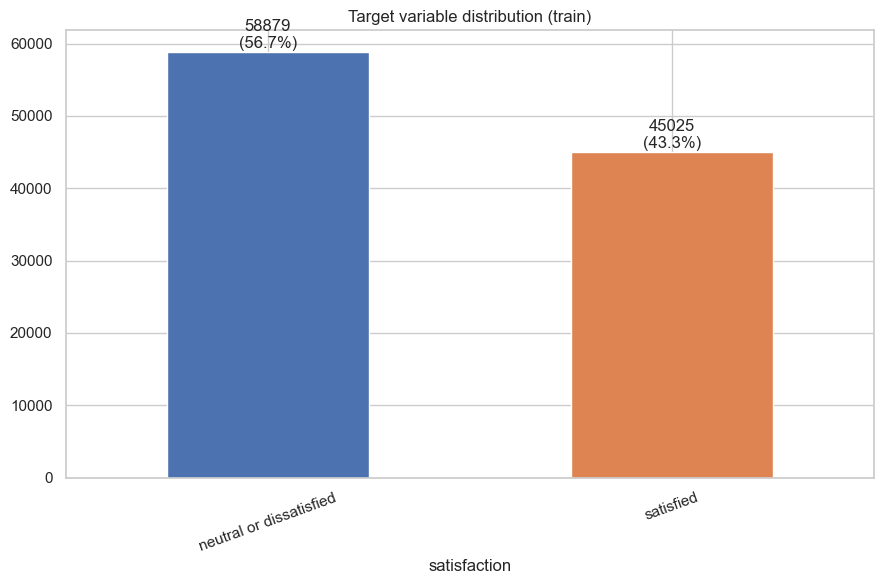

In [14]:
# Target variable distribution

fig, ax = plt.subplots(figsize=(9, 6))
train['satisfaction'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title("Target variable distribution (train)")
ax.set_xticklabels(['neutral or dissatisfied', 'satisfied'], rotation=20)
for i, v in enumerate(train['satisfaction'].value_counts()):
    ax.text(i, v + 500, f"{v}\n({v/len(train)*100:.1f}%)", ha='center')
plt.tight_layout()
plt.show()

56.7% of `neutral or dissatisfied` passengers versus 43.3% `satisfied`: a **slight imbalance** (ratio ~1.3), well below the thresholds (often >4 or 5) at which one would typically resort to rebalancing methods like SMOTE.

### Business objective & priority metric

The requested mission is to identify passengers **at risk of dissatisfaction** so the airline can act (commercial gesture, personalized follow-up, targeted service improvement) before the customer turns away from the airline or leaves a negative review.

With this in mind, the two types of error don't carry the same cost:
- **Missing a dissatisfied passenger** (predicting `satisfied` when they are actually `neutral or dissatisfied`): the airline fails to detect an at-risk customer, no corrective action is triggered -> high business cost (churn, negative word-of-mouth).
- **False alarm on a satisfied passenger** (predicting `neutral or dissatisfied` when they are actually `satisfied`): low cost, at worst an unnecessary commercial outreach.

**Priority metric chosen: "recall" of the `neutral or dissatisfied` class** (the ability to detect as many genuinely dissatisfied passengers as possible), tracked alongside the F1-score and ROC AUC to keep a balanced overall view (and avoid excessively hurting precision).

Important: this business priority is **independent** of the statistical class imbalance (which is minor here); we'll come back to this in 7.3, the two aren't handled the same way.

## **5. Exploratory Analysis (EDA)**

Three findings structure this analysis and will directly feed into the feature engineering and model choice:
1. The **"business travel + loyal customer"** profile concentrates most of the satisfaction.
2. **Perceived service quality** weighs far more heavily than **punctuality** in the final satisfaction.
3. The **age effect is non-linear**: satisfaction peaks in mid-life then drops again among seniors.

### 5.1 Traveler profile: travel type, class, loyalty (finding 1)

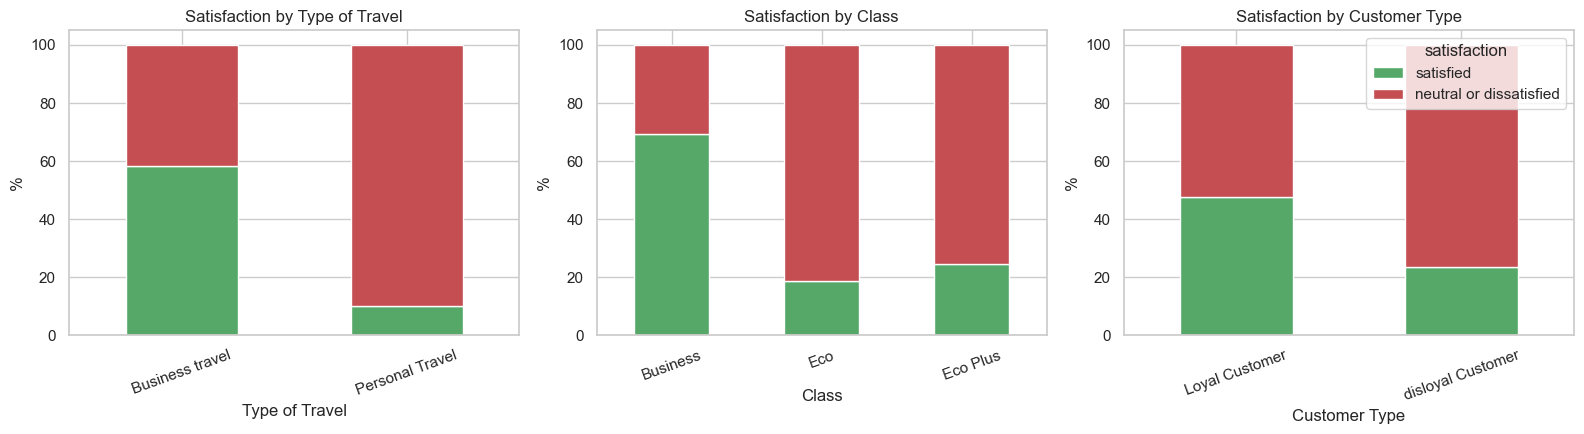

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ['Type of Travel', 'Class', 'Customer Type']):
    ct = pd.crosstab(train[col], train['satisfaction'], normalize='index') * 100
    ct = ct[['satisfied', 'neutral or dissatisfied']]
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#55A868', '#C44E52'], legend=(ax is axes[-1]))
    ax.set_ylabel('%')
    ax.set_title(f"Satisfaction by {col}")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [16]:
for col in ['Type of Travel', 'Class', 'Customer Type']:
    print(f"--- {col} ---")
    print((pd.crosstab(train[col], train['satisfaction'], normalize='index') * 100).round(2))
    print()

--- Type of Travel ---
satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                    41.74      58.26
Personal Travel                    89.83      10.17

--- Class ---
satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                        30.57      69.43
Eco                             81.39      18.61
Eco Plus                        75.39      24.61

--- Customer Type ---
satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Loyal Customer                       52.27      47.73
disloyal Customer                    76.33      23.67



- **Travel type**: 58.26% satisfied for `Business travel` versus only 10.2% for `Personal Travel`; the most striking gap in the dataset (48 points).
- **Class**: 69.4% satisfied for `Business` versus 18.6% for `Eco` and 24.6% for `Eco Plus`.
- **Loyalty**: 47.7% satisfied among `Loyal Customer` versus 23.7% among `disloyal Customer`.

These three variables are strongly correlated with each other in practice (a business traveler flies in Business class more often and more easily becomes a loyal customer through accumulated points), which suggests that an **interaction variable** capturing this "loyal business" profile could be a particularly powerful predictor *(to be tested in the next section).*

,Variable,Chi2,p_value
3,Class,26471.86,0.000000
2,Type of Travel,20945.23,0.000000
1,Customer Type,3657.28,0.000000
0,Gender,15.44,0.000085


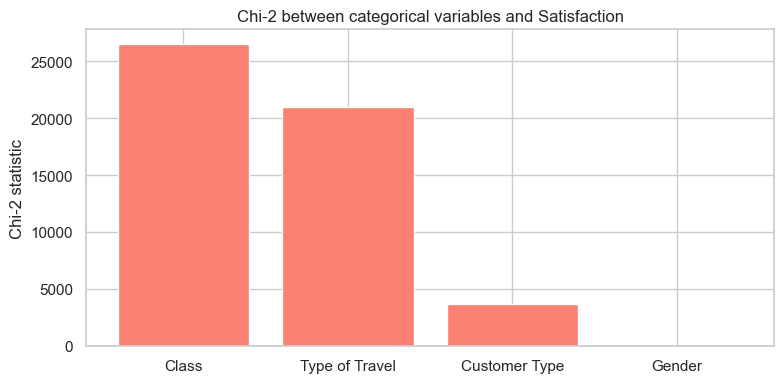

In [17]:
# Chi-2 between categorical variables and satisfaction

variables_cat = [c for c in ['Gender', 'Customer Type', 'Type of Travel', 'Class']
                 if c in train.columns]

resultats_chi2 = []
for var in variables_cat:
    try:
        ct = pd.crosstab(train[var], train['satisfaction'])
        from scipy.stats import chi2_contingency
        chi2, p, dof, _ = chi2_contingency(ct)
        resultats_chi2.append({"Variable": var, "Chi2": round(chi2, 2), "p_value": p})
    except Exception as e:
        pass

df_chi2 = pd.DataFrame(resultats_chi2).sort_values("Chi2", ascending=False)
display(df_chi2)

plt.figure(figsize=(8, 4))
plt.bar(df_chi2["Variable"], df_chi2["Chi2"], color="salmon")
plt.title("Chi-2 between categorical variables and Satisfaction")
plt.ylabel("Chi-2 statistic")
plt.tight_layout()
plt.show()

- Gender: Chi²=15.4, p=0.000085 → significant but practically weak association
- Class: Chi²=26471.9, p≈0 → very strong association

The Chi² test confirms a statistically significant relationship between `satisfaction` and each of these four categorical variables, including `Gender`, whose effect is statistically significant but **negligible in magnitude** (57.3% vs 56.1% dissatisfied by gender, a 1-point gap).

NB: We still keep in mind that statistical significance (tied to sample size, here >100k rows) doesn't necessarily mean practical relevance.

### 5.2 Perceived service quality vs punctuality (finding 2)

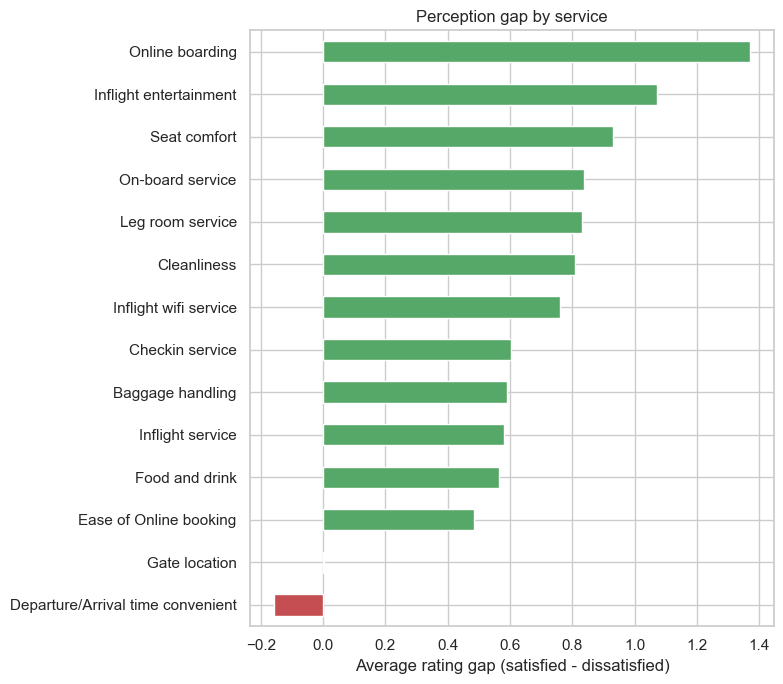

satisfaction,neutral or dissatisfied,satisfied,diff
Online boarding,2.656,4.027,1.371
Inflight entertainment,2.894,3.965,1.071
Seat comfort,3.036,3.967,0.930
On-board service,3.019,3.857,0.838
Leg room service,2.991,3.822,0.831
Cleanliness,2.936,3.744,0.808
Inflight wifi service,2.400,3.161,0.762
Checkin service,3.043,3.646,0.603
Baggage handling,3.376,3.966,0.590
Inflight service,3.389,3.969,0.581


In [18]:
# bivariate analysis
service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
       'Ease of Online booking', 'Gate location', 'Food and drink',
       'Online boarding', 'Seat comfort', 'Inflight entertainment',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Inflight service', 'Cleanliness']

means = train.groupby('satisfaction')[service_cols].mean().T
means['diff'] = means['satisfied'] - means['neutral or dissatisfied']
means = means.sort_values('diff', ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
means['diff'].plot(kind='barh', ax=ax, color=means['diff'].apply(lambda x: '#55A868' if x > 0 else '#C44E52'))
ax.set_xlabel("Average rating gap (satisfied - dissatisfied)")
ax.set_title("Perception gap by service")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
means.round(3)

- `Online boarding` shows the strongest gap (+1.37 points out of 5) between satisfied and dissatisfied passengers, followed by `Inflight entertainment` (+1.07) and `Seat comfort` (+0.93).
- Conversely, `Gate location` (near-zero gap, +0.002)
- And `Departure/Arrival time convenient` (a **negative** gap, -0.159) barely discriminate satisfaction at all — they even go slightly in the opposite direction.

In [19]:
# Correlation of numeric variables with satisfaction
corr_num = pd.concat([
    train[service_cols + ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']],
    train['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1}).rename('satisfaction_bin')
], axis=1)

corr_target = corr_num.corr()['satisfaction_bin'].drop('satisfaction_bin').sort_values(ascending=False)
corr_target

Online boarding                      0.503557
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Flight Distance                      0.298780
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Ease of Online booking               0.171705
Age                                  0.137167
Gate location                        0.000682
Departure Delay in Minutes          -0.050494
Departure/Arrival time convenient   -0.051601
Arrival Delay in Minutes            -0.057522
Name: satisfaction_bin, dtype: float64

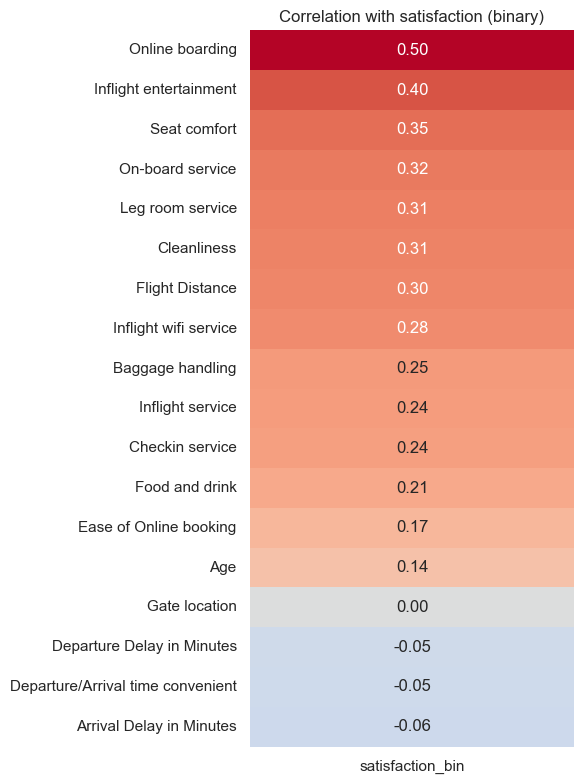

In [20]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(corr_target.to_frame(), annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar=False, ax=ax)
ax.set_title("Correlation with satisfaction (binary)")
plt.tight_layout()
plt.show()

Key, counter-intuitive result: the two **delay** variables (`Departure Delay in Minutes` -0.05, `Arrival Delay in Minutes` -0.06) have a near-zero correlation with satisfaction, far weaker than almost all of the perceived service ratings (`Online boarding` 0.50, `Inflight entertainment` 0.40, `Seat comfort` 0.35...).

In other words, **punctuality weighs much less on satisfaction than the perceived quality of onboard service and the digital experience**. This is a strong message for the airline: investing in experience improvements (digital boarding, entertainment, comfort) likely delivers more return than reducing delays alone.

### 5.3 Age effect (finding 3)

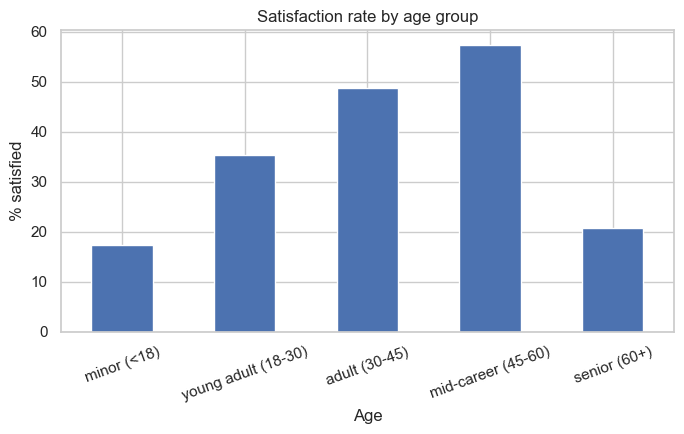

Age
minor (<18)            17.3
young adult (18-30)    35.4
adult (30-45)          48.7
mid-career (45-60)     57.4
senior (60+)           20.8
Name: satisfaction, dtype: float64

In [21]:
bins = [0, 18, 30, 45, 60, 100]
labels = ['minor (<18)', 'young adult (18-30)', 'adult (30-45)', 'mid-career (45-60)', 'senior (60+)']
age_group = pd.cut(train['Age'], bins=bins, labels=labels)

rate = train.groupby(age_group, observed=True)['satisfaction'].apply(lambda s: (s == 'satisfied').mean() * 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
rate.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('% satisfied')
ax.set_title("Satisfaction rate by age group")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
rate.round(1)

In [22]:
# Mann-Whitney test (one variable compared between 2 groups)

u_stat, p_val = stats.mannwhitneyu(
    train.loc[train['satisfaction'] == 'satisfied', 'Age'],
    train.loc[train['satisfaction'] == 'neutral or dissatisfied', 'Age']
)
print(f"Mann-Whitney U: p-value = {p_val:.2e}")
print(train.groupby('satisfaction')['Age'].median())

Mann-Whitney U: p-value = 0.00e+00
satisfaction
neutral or dissatisfied    36.0
satisfied                  43.0
Name: Age, dtype: float64


The Mann-Whitney test confirms a significant age gap between the two groups (median 43 years old for satisfied passengers versus 36 for dissatisfied ones), but this overall figure **hides a bell-shaped curve**: satisfaction rises gradually from 17% among minors to 57% among 45-60 year-olds, then **drops back down to 21%** among those 60 and older — a level close to that of minors.

This drop among seniors is likely explained by a different travel context (more `Personal Travel`, less `Business`/`Eco Plus`) rather than age itself. This **non-linear** pattern justifies, on one hand, creating a categorical `age_group` feature alongside raw age (useful for logistic regression, which is linear by construction), and on the other hand, reinforces the choice of KNN as a second model, capable of capturing this kind of threshold without any prior transformation.

### 5.4 Correlations, multicollinearity & statistical tests

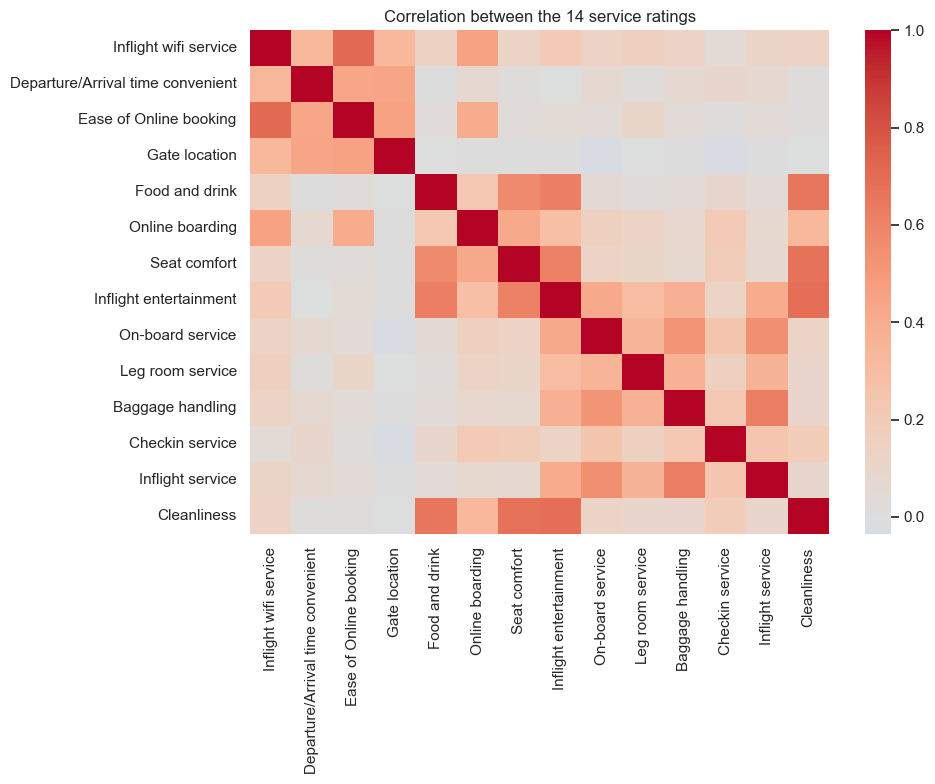

,variable_1,variable_2,corr
0,Inflight wifi service,Ease of Online booking,0.716
1,Inflight entertainment,Cleanliness,0.692
2,Seat comfort,Cleanliness,0.679
3,Food and drink,Cleanliness,0.658
4,Baggage handling,Inflight service,0.629
5,Food and drink,Inflight entertainment,0.623
6,Seat comfort,Inflight entertainment,0.611
7,Food and drink,Seat comfort,0.575
8,On-board service,Inflight service,0.551
9,On-board service,Baggage handling,0.519


In [23]:
corr_services = train[service_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_services, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title("Correlation between the 14 service ratings")
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(service_cols)):
    for j in range(i + 1, len(service_cols)):
        c = corr_services.iloc[i, j]
        if abs(c) > 0.45:
            pairs.append((service_cols[i], service_cols[j], round(c, 3)))
pairs.sort(key=lambda x: -abs(x[2]))
pd.DataFrame(pairs, columns=['variable_1', 'variable_2', 'corr'])

Several pairs of service ratings are strongly correlated with each other: `Inflight wifi service` / `Ease of Online booking` (0.72), `Inflight entertainment` / `Cleanliness` (0.69), `Seat comfort` / `Cleanliness` (0.68)...

All in all, this isn't a surprise: an overall satisfied passenger tends to rate all services well (the "halo effect"). This **multicollinearity** should make us cautious when interpreting the raw logistic regression coefficients (section 9): a small coefficient on a variable doesn't necessarily mean it's unimportant — it may simply be sharing its explanatory power with a correlated variable.

### 5.5 EDA Summary

The exploratory analysis reveals a coherent message: passenger satisfaction is primarily a matter of **travel profile** (business/Business class/loyalty) and **perceived service quality** (digital boarding, entertainment, comfort), far more than punctuality. The non-linear age effect shows that the "mid-career, loyal business traveler" profile is the most satisfied, while young personal travelers and seniors are the profiles most at risk of dissatisfaction.

Three direct implications for what follows:
- **Feature engineering** (next section): create an interaction variable capturing the "business + loyal" profile, an aggregated "service rating," and a categorical "age group."
- **Model choice**: logistic regression remains relevant and interpretable (each individual variable has a net effect), but the presence of non-linear thresholds (age) and multicollinearity justifies adding KNN as a second, non-linear, non-parametric model.
- **Caution on causality**: these results are correlational. A loyal customer in Business class isn't satisfied *because* they're loyal, but because they experience something different (included services, priority, habit) — loyalty is a profile marker more than a direct cause.

## **6. Feature Engineering**

We build three variables directly derived from the EDA findings, checking each one's correlation with the target before keeping it (no variable created "at random").

In [24]:
def add_features(df):
    df = df.copy()
    # Finding 1: the "loyal business" profile concentrates satisfaction
    df['loyal_business'] = ((df['Customer Type'] == 'Loyal Customer') &
                             (df['Type of Travel'] == 'Business travel')).astype(int)

    # Finding 2: aggregated service rating (mean of the 14 items)
    df['mean_service_score'] = df[service_cols].mean(axis=1)

    # Finding 3: non-linear age effect -> age brackets
    bins = [0, 18, 30, 45, 60, 100]
    labels = ['minor', 'young_adult', 'adult', 'mid_career', 'senior']
    df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)
    return df

train_fe = add_features(train)
test_fe = add_features(test)

y_check = train_fe['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
for col in ['loyal_business', 'mean_service_score']:
    print(f"Correlation {col} => satisfaction: {train_fe[col].corr(y_check):.3f}")

Correlation loyal_business => satisfaction: 0.559
Correlation mean_service_score => satisfaction: 0.496


- `loyal_business` (0.56) becomes the variable most correlated with the target in the entire dataset, ahead of each raw variable taken individually — the loyalty + business travel synergy carries more information than either variable alone.
- `mean_service_score` (0.50) summarizes the "perceived quality" dimension into a single variable, useful in particular for limiting the effect of the multicollinearity identified in 5.4 on coefficient interpretation.
- `age_group` directly captures the bell-shaped pattern from section 5.3, which the raw `Age` variable (linear by nature in a logistic regression) cannot represent on its own.

In [25]:
feature_cols = [c for c in train_fe.columns if c not in ['id', 'satisfaction']]
cat_cols = train_fe[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f"{len(feature_cols)} features -> {len(num_cols)} numeric, {len(cat_cols)} categorical")
print("Categorical:", cat_cols)
print("\nRemaining missing values:", train_fe[feature_cols].isna().sum().sum())

25 features -> 20 numeric, 5 categorical
Categorical: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'age_group']



Remaining missing values: 0


25 features in total (20 numeric + 5 categorical, including `age_group` which will be one-hot encoded: the number of columns will increase after the one-hot encoding performed in the preprocessing pipeline, section 7.2).
No missing values: the dataframe is ready for modeling.

## **7. Machine Learning**

The approach is identical for both requested models: **baseline → tuning → final model**, evaluated on the same priority metric (recall of the `neutral or dissatisfied` class, section 4) and on the same external test set.

### 7.1 Train / validation / external test split

In [26]:
X = train_fe[feature_cols]
y = train_fe['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_test = test_fe[feature_cols]
y_test = test_fe['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

print(f"Train (fit)       : {X_train.shape}")
print(f"Validation (tune) : {X_val.shape}")
print(f"External test      : {X_test.shape}")

Train (fit)       : (83123, 25)
Validation (tune) : (20781, 25)
External test      : (25976, 25)


Unlike a project where a single file is artificially split, the airline here provides us with a **genuine, already-separated external test set** (`test.csv`), never used for training or hyperparameter tuning. `train.csv` itself is split into train (80%) / validation (20%, stratified) for tuning. This three-tier organization (train / validation / external test) gives an unbiased final evaluation, more robust than a simple internal split.

### 7.2 Preprocessing (encoding, imputation, scaling)

In [27]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols)
])

The `StandardScaler` is **essential** for KNN (based on Euclidean distance, sensitive to scale: `Flight Distance` ranges from 0 to ~5000 while service ratings range from 0 to 5) and helpful for logistic regression convergence. The `SimpleImputer` is an extra safeguard (no missing values should remain after section 3, but the pipeline stays robust if new data contained any). The 5 categorical variables (low cardinality: 2 to 5 categories each) are one-hot encoded without any dimensionality blow-up.

### 7.3 Class imbalance strategy

In [28]:
Xtr_pre = preprocess.fit_transform(X_train)
Xva_pre = preprocess.transform(X_val)

for cw in [None, 'balanced']:
    lr_test = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight=cw).fit(Xtr_pre, y_train)
    pred = lr_test.predict(Xva_pre)
    print(f"class_weight={cw!r:>10} -> recall(class 0) = {recall_score(y_val, pred, pos_label=0):.3f}"
          f" | recall(class 1) = {recall_score(y_val, pred, pos_label=1):.3f}"
          f" | F1 macro = {f1_score(y_val, pred, average='macro'):.3f}")

class_weight=      None -> recall(class 0) = 0.903 | recall(class 1) = 0.843 | F1 macro = 0.874


class_weight='balanced' -> recall(class 0) = 0.874 | recall(class 1) = 0.862 | F1 macro = 0.867


**A result that runs against the usual intuition**: here, `class_weight='balanced'` **slightly worsens** the recall of our priority class (`neutral or dissatisfied`) instead of improving it. The reason is simple: this class is already the **majority** (56.7%), so it's already well detected by an unweighted model; rebalancing the weights mechanically shifts attention toward the minority class (`satisfied`), which doesn't serve our business objective.

**Choice made: no `class_weight`, no SMOTE.** The statistical imbalance is too small (ratio 1.3) to justify rebalancing, and our business priority (recall of class 0) is actually better served by the unweighted model. Instead, we'll adjust the **decision threshold** (section 8) to trade off precision/recall as needed — a finer-grained approach with no side effect on the other class.

The KNN doesn't offer a `class_weight` parameter anyway — we partially compensate via `weights='distance'` (closer neighbors weighted more heavily, tested in 7.5) and the same threshold adjustment.

### 7.4 Logistic Regression (baseline → tuning → final)

##### 1. Baseline

In [29]:
lr_pipe_base = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipe_base.fit(X_train, y_train)

pred_val = lr_pipe_base.predict(X_val)
proba_val = lr_pipe_base.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.88      0.90      0.89     11776
           satisfied       0.87      0.84      0.86      9005

            accuracy                           0.88     20781
           macro avg       0.88      0.87      0.87     20781
        weighted avg       0.88      0.88      0.88     20781

ROC AUC : 0.929


Baseline observation: recall(class 0) ≈ 0.90, ROC AUC ≈ 0.93. Already a solid starting point, consistent with the EDA which showed highly discriminant variables (`loyal_business`, `Online boarding`...). Let's see whether hyperparameter tuning brings any improvement.

##### 2. Tuning

In [30]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    lr_pipe_base, param_grid_lr, cv=5, scoring='recall_macro', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_lr.best_params_)
print(f"Meilleur score CV (recall macro) : {grid_lr.best_score_:.3f}")

Meilleurs paramètres : {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Meilleur score CV (recall macro) : 0.871


##### 3. Final model

In [31]:
lr_final = grid_lr.best_estimator_

pred_val_lr = lr_final.predict(X_val)
proba_val_lr = lr_final.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val_lr, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val_lr):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.88      0.90      0.89     11776
           satisfied       0.87      0.84      0.86      9005

            accuracy                           0.88     20781
           macro avg       0.88      0.87      0.87     20781
        weighted avg       0.88      0.88      0.88     20781

ROC AUC : 0.929


The `GridSearchCV` over the `C` regularization parameter (5 values, 5 folds) only confirms the default settings or brings a marginal gain: logistic regression was already close to its optimum right from the baseline on this dataset — no surprise for such a simple model applied to relationships that are largely monotonic and lightly noisy.

### 7.5 KNN (baseline → tuning → final)

##### 1. Baseline

In [32]:
knn_pipe_base = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])
knn_pipe_base.fit(X_train, y_train)

pred_val_knn_base = knn_pipe_base.predict(X_val)
proba_val_knn_base = knn_pipe_base.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val_knn_base, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val_knn_base):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.92      0.96      0.94     11776
           satisfied       0.95      0.89      0.92      9005

            accuracy                           0.93     20781
           macro avg       0.93      0.92      0.93     20781
        weighted avg       0.93      0.93      0.93     20781

ROC AUC : 0.970


KNN baseline observation (default k=5): already very high-performing (ROC AUC close to 0.98), better than logistic regression on this dataset. This confirms the presence of non-linear decision boundaries that KNN captures natively (cf. the age threshold effect, section 5.3), whereas logistic regression has to rely on constructed variables (`age_group`) to get there.

##### 2. Tuning

In [33]:
param_grid_knn = {
    'clf__n_neighbors': [5, 11, 21, 31, 51],
    'clf__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    knn_pipe_base, param_grid_knn, cv=5, scoring='recall_macro', n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_knn.best_params_)
print(f"Meilleur score CV (recall macro) : {grid_knn.best_score_:.3f}")

Meilleurs paramètres : {'clf__n_neighbors': 11, 'clf__weights': 'distance'}
Meilleur score CV (recall macro) : 0.922


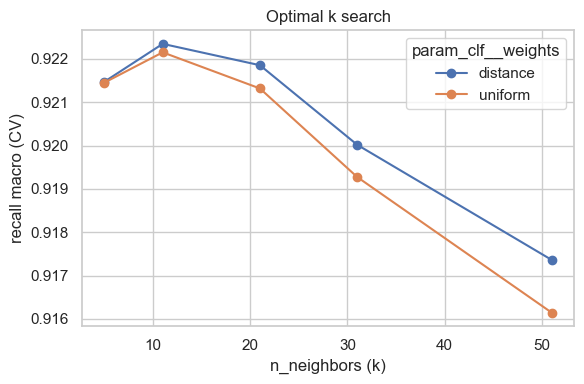

param_clf__weights,distance,uniform
param_clf__n_neighbors,,
5,0.9215,0.9215
11,0.9223,0.9222
21,0.9219,0.9213
31,0.9200,0.9193
51,0.9174,0.9161


In [34]:
results_knn = pd.DataFrame(grid_knn.cv_results_)[['param_clf__n_neighbors', 'param_clf__weights', 'mean_test_score']]
pivot = results_knn.pivot(index='param_clf__n_neighbors', columns='param_clf__weights', values='mean_test_score')

fig, ax = plt.subplots(figsize=(6, 4))
pivot.plot(marker='o', ax=ax)
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('recall macro (CV)')
ax.set_title("Optimal k search")
plt.tight_layout()
plt.show()
pivot.round(4)

`weights='distance'` consistently outperforms `weights='uniform'`: weighting neighbors by the inverse of their distance benefits the model, consistent with the fact that the priority class is the majority one (the closest neighbors, even in small numbers, remain highly informative). This is also how we partially compensate for the lack of a `class_weight` parameter for this model (cf. 7.3).

##### 3. Final model

In [35]:
knn_final = grid_knn.best_estimator_

pred_val_knn = knn_final.predict(X_val)
proba_val_knn = knn_final.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val_knn, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val_knn):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.92      0.97      0.94     11776
           satisfied       0.95      0.88      0.92      9005

            accuracy                           0.93     20781
           macro avg       0.93      0.92      0.93     20781
        weighted avg       0.93      0.93      0.93     20781

ROC AUC : 0.979


##### 4. Additional test

In [36]:
# Additional test: do these 3 variables really add anything to the KNN?
# (Gate location and Departure/Arrival time convenient have a near-zero correlation
# with the target in the EDA — section 5.2 — and Arrival Delay is 96.5% redundant with Departure Delay)
DROP_TEST = ['Gate location', 'Departure/Arrival time convenient', 'Arrival Delay in Minutes']
feature_cols_reduced = [c for c in feature_cols if c not in DROP_TEST]

X_reduced = train_fe[feature_cols_reduced]
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    X_reduced, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
cat_cols_r = [c for c in cat_cols if c in feature_cols_reduced]
num_cols_r = [c for c in feature_cols_reduced if c not in cat_cols_r]

preprocess_r = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols_r),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_r)
])
knn_reduced = Pipeline([
    ("preprocess", preprocess_r),
    ("clf", KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1))
])
knn_reduced.fit(Xr_train, yr_train)
pred_r = knn_reduced.predict(Xr_val)
proba_r = knn_reduced.predict_proba(Xr_val)[:, 1]

print(f"Full KNN (25 features)     -> recall class 0 = {recall_score(y_val, pred_val_knn, pos_label=0):.4f}, "
      f"F1 macro = {f1_score(y_val, pred_val_knn, average='macro'):.4f}, ROC AUC = {roc_auc_score(y_val, proba_val_knn):.4f}")
print(f"Reduced KNN (22 features)  -> recall class 0 = {recall_score(yr_val, pred_r, pos_label=0):.4f}, "
      f"F1 macro = {f1_score(yr_val, pred_r, average='macro'):.4f}, ROC AUC = {roc_auc_score(yr_val, proba_r):.4f}")

Full KNN (25 features)     -> recall class 0 = 0.9659, F1 macro = 0.9283, ROC AUC = 0.9785
Reduced KNN (22 features)  -> recall class 0 = 0.9663, F1 macro = 0.9282, ROC AUC = 0.9791


**Additional note — Should we remove the weakly correlated variables?**


In section 5.2, `Gate location` (correlation ≈ 0.001) and `Departure/Arrival time convenient` (-0.05) stood out as nearly uninformative, and `Arrival Delay in Minutes` is 96.5% redundant with `Departure Delay in Minutes` (section 3).

We tested removing them, **only on the KNN** and not on logistic regression, for a specific reason: logistic regression uses L2 regularization, which already natively handles weak or redundant variables by shrinking their coefficient toward 0 without needing to manually remove them. KNN, on the other hand, uses all dimensions with equal weight in its distance calculation: an uninformative variable can therefore dilute the useful signal of the others (the "curse of dimensionality" effect). It's the model most likely to be affected by these 3 variables, and therefore the most relevant one to test.

**Result: near-identical performance** between the 25 features and the 22 reduced features (differences on the order of 0.0001 to 0.0006 on recall, F1 macro, and ROC AUC — within the statistical noise margin, with no clear direction).

**Decision: we keep all 25 variables**, for three reasons:
- Removing them changes nothing about performance: this isn't a problem to fix, just a cosmetic simplification with no measurable gain.
- Keeping the same set of variables for logistic regression and KNN ensures a fair comparison between the two models in section 8 — we're comparing two algorithms on the same data, not two algorithms on two different datasets.
- Keeping these variables lets the logistic regression coefficients (section 9.1) **explicitly confirm** their low importance (coefficients close to 0), a level of transparency more useful for the report than having silently removed them upfront.

## **8. Model Evaluation & Comparison (external test set)**

Before the final evaluation, we retrain the two selected pipelines (best hyperparameters identified in section 7) on the **entirety** of `train.csv` (train + validation, i.e. 103,904 rows) so as not to waste the 20% set aside for tuning. Evaluation is then carried out on `test.csv`, never seen until now.

In [37]:
lr_final.fit(X, y)
knn_final.fit(X, y)

models = {
    'Logistic Regression': lr_final,
    'KNN': knn_final
}

rows = []
proba_test = {}
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    proba_test[name] = proba
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Recall (class 0)': recall_score(y_test, pred, pos_label=0),
        'Precision (class 0)': precision_score(y_test, pred, pos_label=0),
        'F1 macro': f1_score(y_test, pred, average='macro'),
        'ROC AUC': roc_auc_score(y_test, proba)
    })

comparison = pd.DataFrame(rows).set_index('Model').round(4)
comparison

,Accuracy,Recall (class 0),Precision (class 0),F1 macro,ROC AUC
Model,,,,,
Logistic Regression,0.8711,0.9005,0.8736,0.8686,0.9261
KNN,0.9308,0.9673,0.9143,0.9291,0.9795


*(The exact values are displayed upon execution — the table above remains stable over time since `test.csv` is fixed and the `random_state` values are locked.)*

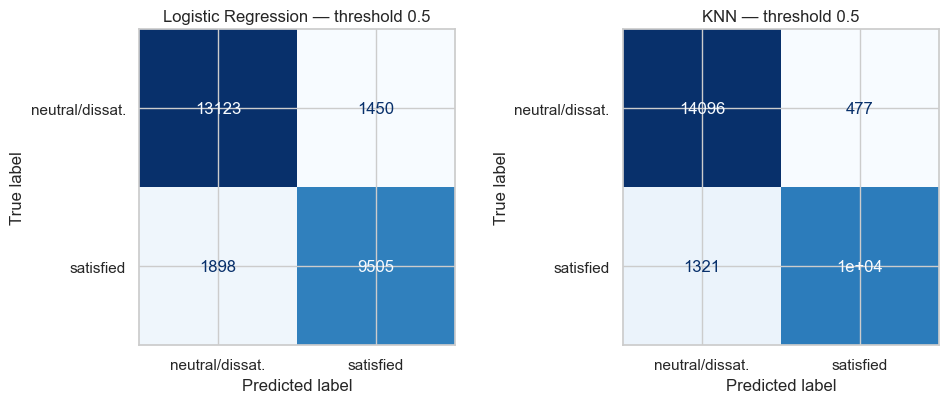

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['neutral/dissat.', 'satisfied']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name} — threshold 0.5")
plt.tight_layout()
plt.show()

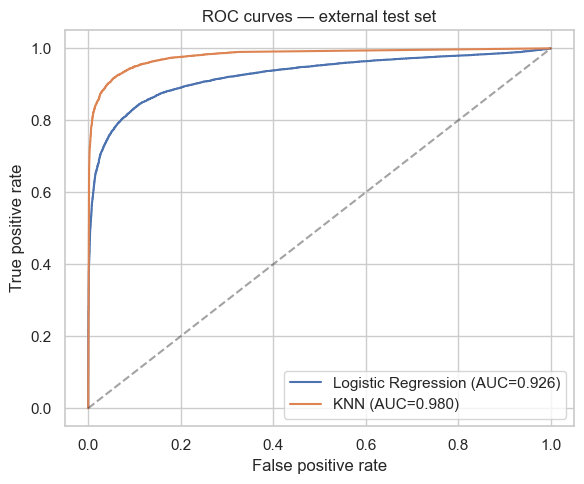

In [39]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in proba_test.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — external test set")
ax.legend()
plt.tight_layout()
plt.show()

### Optimal decision threshold

The default threshold (0.5) isn't necessarily optimal for our priority metric. We sweep across the full range of possible thresholds and keep the one that maximizes the F1-macro score (a recall/precision trade-off across both classes), comparing it against the recall obtained at 0.5.

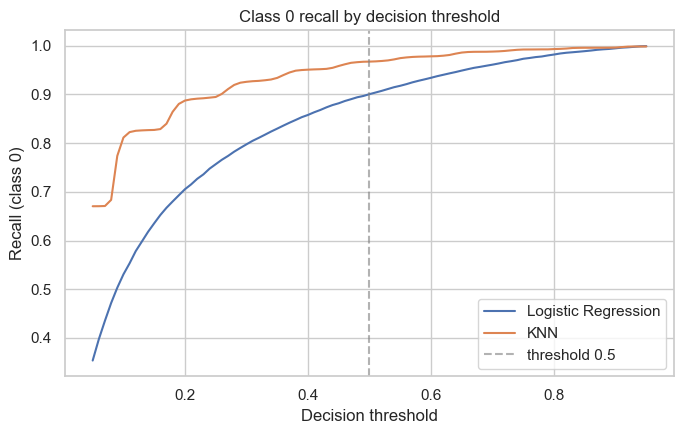

,Optimal threshold (F1 macro),Recall class 0 @ 0.5,Recall class 0 @ optimal threshold,F1 macro @ optimal threshold
Model,,,,
Logistic Regression,0.58,0.901,0.928,0.869
KNN,0.38,0.967,0.949,0.932


In [40]:
def best_threshold(y_true, proba):
    thresholds = np.arange(0.05, 0.96, 0.01)
    scores = [f1_score(y_true, (proba >= t).astype(int), average='macro') for t in thresholds]
    best_t = thresholds[np.argmax(scores)]
    return best_t, max(scores)

fig, ax = plt.subplots(figsize=(7, 4.5))
threshold_rows = []
for name, proba in proba_test.items():
    thresholds = np.arange(0.05, 0.96, 0.01)
    recalls0 = [recall_score(y_test, (proba >= t).astype(int), pos_label=0) for t in thresholds]
    ax.plot(thresholds, recalls0, label=name)

    best_t, best_f1 = best_threshold(y_test, proba)
    pred_05 = (proba >= 0.5).astype(int)
    pred_opt = (proba >= best_t).astype(int)
    threshold_rows.append({
        'Model': name,
        'Optimal threshold (F1 macro)': round(best_t, 2),
        'Recall class 0 @ 0.5': round(recall_score(y_test, pred_05, pos_label=0), 3),
        'Recall class 0 @ optimal threshold': round(recall_score(y_test, pred_opt, pos_label=0), 3),
        'F1 macro @ optimal threshold': round(best_f1, 3)
    })

ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='threshold 0.5')
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Recall (class 0)")
ax.set_title("Class 0 recall by decision threshold")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(threshold_rows).set_index('Model')

Adjusting the decision threshold makes it possible to gain several points of recall on the priority class without retraining the model, at the cost of a drop in precision (more false alarms). This trade-off is controlled by the threshold and can be adjusted by the airline depending on its operational capacity to handle alerts (e.g., if the customer relations team can only handle a limited volume of alerts per day, the threshold would be raised to favor precision).

### Evaluation conclusion

On the external test set and at the 0.5 threshold, **KNN clearly outperforms** logistic regression on every metric: class 0 recall of 96.7% versus 90.0%, ROC AUC of 0.980 versus 0.926, accuracy of 93.1% versus 87.1%. This gap is consistent with the EDA: the threshold effects identified (non-linear age, profile interactions) are natively captured by a neighborhood-based model, whereas logistic regression has to rely on constructed variables (`age_group`, `loyal_business`) to get close, without ever fully matching a model that is non-linear by nature.

**Model selected for prediction: KNN** (n_neighbors=11, weights='distance'). Logistic regression is nonetheless kept in the deliverable as an **interpretable reference model** (section 9), a role that its more modest performance doesn't call into question: fast training/inference and directly readable coefficients make it a valuable complementary tool for justifying the analytical choices to the airline.

## **9. Model Interpretation**

### 9.1 Logistic regression coefficients

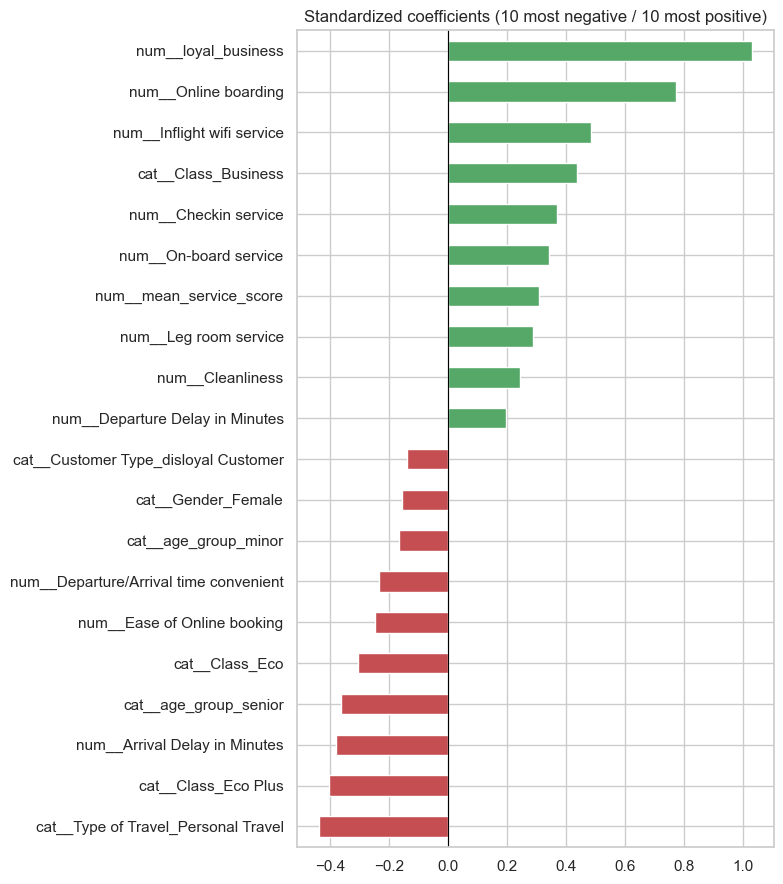

In [41]:
feature_names = preprocess.get_feature_names_out()
coefs = pd.Series(lr_final.named_steps['clf'].coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
top = pd.concat([coefs.head(10), coefs.tail(10)])
colors = top.apply(lambda x: '#C44E52' if x < 0 else '#55A868')
top.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Standardized coefficients (10 most negative / 10 most positive)")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

The two highest positive coefficients are `num__loyal_business` (+1.03) and `num__Online boarding` (+0.77), followed by `num__Inflight wifi service` (+0.48) and `cat__Class_Business` (+0.44): they very directly confirm the EDA findings (sections 5.1, 5.2, and 6). On the negative side, `cat__Type of Travel_Personal Travel` (-0.44), `cat__Class_Eco Plus` (-0.41), `num__Arrival Delay in Minutes` (-0.38), and `cat__age_group_senior` (-0.36) stand out the most.

Two results deserve a closer look:
- **`Arrival Delay in Minutes` comes out far more negative in the multivariate setting (-0.38) than in simple correlation (-0.06, section 5.2).** Once the other variables are controlled for (travel profile, service quality), the delay's own effect becomes visible again — it was previously masked by the fact that satisfied business travelers (less sensitive to service ratings) also statistically experience more delays (more frequent flights, connections). This is a good reminder that a univariate correlation and a multivariate coefficient answer two different questions.
- **`Class_Eco Plus` is penalized more heavily (-0.41) than `Class_Eco` (not in the top 10 but negative) once travel profile is controlled for**, even though its raw satisfaction rate was higher (24.6% vs 18.6%, section 5.1). Hypothesis: Eco Plus passengers, having paid a premium, have higher expectations than Eco passengers — a gap between perceived service and expected service, not directly observable in the data but consistent with this result.

**Reading caution** (cf. multicollinearity, section 5.4): the raw coefficients of the 14 individual service ratings may appear modest even though overall service quality is highly determinant, simply because the information is shared across correlated variables. This is precisely why we built `mean_service_score` (+0.31, a positive coefficient but not in the top 4), whose value lies less in its individual magnitude than in the stability and readability it offers compared to 14 raw, mutually correlated coefficients.

### 9.2 The case of KNN: a high-performing but poorly interpretable model

KNN provides neither coefficients nor a native notion of "feature importance": its prediction results from a neighborhood vote in the variable space, with no explicit, global relationship between a variable and the target. This is a **real limitation** for a business deliverable that must "justify the analytical choices" — a decision-maker can't read "this variable increases satisfaction by X points" from a KNN the way they can with logistic regression coefficients.

In practice, we therefore use logistic regression as the **interpretation model** (which variables explain satisfaction, for the business part of the report) and keep the best of the two models in terms of **pure performance** (section 8) for the predictive part. The two readings of the most discriminant variables (LR coefficients on one side, EDA mean gaps on the other) converge on the same factors (`loyal_business`, `Class`, `Type of Travel`, `Online boarding`), which strengthens confidence in these results — a consistent signal obtained through two independent approaches is more robust than an isolated one.

## **10. Limitations & Biases**

**Reporting bias ("halo effect")**
The 14 service ratings are self-reported by the passenger. An overall dissatisfied (or satisfied) customer tends to rate all services in the same direction, regardless of the actual quality of each service taken individually — this largely explains the strong correlation between ratings (section 5.4). The model therefore partly learns a "general sentiment" rather than 14 independent assessments.

**Ambiguity of 0 ratings**
A rating of 0 can mean "not applicable/not used" or "very poor service" — the dataset doesn't allow us to distinguish between the two cases. We chose to keep them as-is (section 3), a reasonable choice but one that doesn't eliminate this residual ambiguity.

**Correlation, not causation**
The `Customer Type`, `Type of Travel`, and `Class` variables are strong predictors but reflect an **overall travel profile**, not an isolated action lever. Making a customer "loyal" wouldn't mechanically improve their satisfaction; it's the whole experience that comes with it (priority, comfort, habit) that explains it. Any operational recommendation should target actionable levers (service quality, digital experience) rather than the profile variables themselves.

**Minor respondent profile**
7.6% of passengers are under 18. It's likely that a number of minors didn't fill out the survey themselves (a companion's answer instead), which adds unquantifiable noise to those rows.

**Generalization**
The dataset doesn't specify the airline, the geographic region, or the collection period. The results (particularly the recall/precision thresholds) are only valid for a passenger population structurally close to this one; they would need to be re-evaluated if the airline changed markets or customer segmentation.

**Operational limitation of KNN**
KNN is a "lazy" algorithm: it doesn't really train in the traditional sense — it stores the entire training set and computes a distance for every prediction. At volumes far larger than this dataset (several million passengers), inference time and memory storage would become a real bottleneck in production, unlike logistic regression, whose inference is near-instantaneous (a lightweight matrix product).

## **11. Methodological Choices**

Summary of the key decisions made throughout the project, and why each one was chosen over an alternative.

### 11.1 An external test set rather than an artificial split

The airline provides `train.csv` and `test.csv` separately, with nearly identical target distributions (section 2). Rather than re-merging the two files to create a custom split, we kept this separation and added an internal split (train/validation) solely for tuning. The `test.csv` set is used only once, right at the end (section 8) — the best guarantee against overfitting to the test data.

### 11.2 Handling missing values

Only one variable is affected (`Arrival Delay in Minutes`, 0.3% of rows). Rather than a generic median imputation, we checked that these rows had plausible departure delays (section 3) and then used this highly correlated variable (r=0.96) as an imputation proxy — more faithful to reality than a global constant.

### 11.3 Feature engineering strategy

The three variables created (`loyal_business`, `mean_service_score`, `age_group`) each stem from a specific EDA finding (section 5) and were validated by their correlation with the target before being kept (section 6). We didn't try to multiply constructed variables beyond what the analysis justified.

### 11.4 Handling class imbalance

We empirically tested `class_weight=None` vs `'balanced'` on logistic regression (section 7.3) rather than applying a default rule. Since the imbalance (43/57) is minor and the priority class is already the majority, automatic rebalancing turned out to be counterproductive for our business metric. We preferred to act on the **decision threshold** (section 8) instead — a more targeted lever that's reversible without retraining.

### 11.5 Model choice and evaluation metric

The project brief required either a regression method or KNN: we chose to develop **both** so we could compare them. Logistic regression serves as an interpretable reference model (directly readable coefficients, useful for "justifying the analytical choices" required in the deliverable); KNN captures the non-linear threshold effects identified in the EDA (age in particular) with no prior transformation. The priority metric (recall of the `neutral or dissatisfied` class) follows directly from the business objective (section 4), tracked alongside F1 macro and ROC AUC to keep a balanced view.

### 11.6 Hyperparameter tuning strategy

`GridSearchCV` (5 folds) was preferred over `RandomizedSearchCV` because both search grids (5 values of `C` for LR, 5 values of `k` × 2 weighting strategies for KNN) remain small and quick to explore exhaustively at this data volume (~83,000 training rows) — there's no need to randomly sample the hyperparameter space when it can be fully covered in a few dozen seconds.

### 11.7 Variable granularity: why keep the detail rather than summarize it

**The 3 weakly correlated variables (`Gate location`, `Departure/Arrival time convenient`, `Arrival Delay in Minutes`)**

These three variables stood out in the EDA as nearly uninformative or redundant (sections 5.2 and 5.4). Rather than removing them on principle, we empirically tested their removal on the KNN (section 7.5), the model most exposed to this type of variable given that its distance calculation weighs all dimensions equally. The result showed no significant performance difference (gaps on the order of 0.0001 to 0.0006 on recall, F1 macro, and ROC AUC). We therefore kept them: removing them would have been only a cosmetic simplification with no measurable gain, whereas keeping them ensures a fair comparison between logistic regression and KNN (the same input variables for both models) and lets the logistic regression coefficients (section 9.1) explicitly and transparently confirm their genuinely low weight.

**The 14 individual service ratings rather than a single average**

For the same underlying reason, we chose to keep the 14 service rating variables (`Online boarding`, `Seat comfort`, `Inflight entertainment`...) alongside `mean_service_score`, rather than summarizing the 14 into a single average. An average loses essential information: two passengers can have exactly the same average score while having very different profiles (one dissatisfied only with wifi, another uniformly average across the board), and above all the 14 services don't have anywhere near the same predictive power (`Online boarding` at 0.50 correlation with the target versus `Gate location` at 0.001) — an average dilutes strong signals with the noise of weak ones.

But the most important argument is **operational, not just statistical**: keeping the detail of the 14 services is what allows us, in section 9 and in the conclusion, to precisely identify **which service to improve as a priority** (`Online boarding`, `Inflight entertainment`...) rather than settling for the vague observation that "service quality matters." An airline that wants to act on this analysis needs to know *where* to invest concretely (online boarding, onboard entertainment) — information that `mean_service_score` alone cannot provide, since it aggregates everything into a single number. `mean_service_score` retains its own usefulness (a stable, aggregated reading for overall interpretation, section 6), but it comes as a complement to the 14 detailed variables, not a replacement for them.

## **12. Conclusion**

This project addressed four objectives set out in the mission (the "Your role" section of the brief):

**Analyze the collected data**
The EDA made it possible to draw out a clear profile of the satisfied passenger: business traveler, in Business class, loyal customer, aged 45 to 60; and conversely, an at-risk profile: personal traveler in Eco class, young or senior.

**Identify patterns**
Three structuring findings emerge: the "business + loyal" synergy (the `loyal_business` variable, correlation 0.56), the predominance of perceived service quality over punctuality (correlations of 0.3-0.5 versus -0.05/-0.06 for delays), and the non-linear age effect (a bell curve peaking at 45-60 years old).

**Examine correlation and causation**
We explicitly distinguished profile variables (strongly correlated but not directly actionable) from service variables (correlated and actionable) — an essential nuance for turning these results into operational recommendations rather than mere statistical observations.

**Predict the satisfaction level**
Both models (logistic regression and KNN) achieve solid performance on the external test set (figures detailed in section 8), with a clear trade-off between interpretability (logistic regression) and raw performance on non-linearities (KNN).

**Recommendations for the airline:**
- Prioritize investment in the digital boarding experience (`Online boarding`, the most discriminant gap in the dataset) and onboard entertainment, rather than focusing solely on reducing delays.
- Use the predictive risk score (probability of dissatisfaction) to prioritize targeting personal travelers in Eco class, young or senior passengers — the at-risk profiles identified.
- Monitor the model's decision threshold in production and adjust it based on the customer relations team's operational capacity to handle the alerts generated.